In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df_sentiment = pd.read_csv("fear_greed_index.csv")
df_trade = pd.read_csv("historical_data.csv")

In [11]:
df_sentiment.head(5)

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [12]:
df_sentiment.shape

(2644, 4)

In [13]:
df_trade.head(5)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [14]:
df_trade.shape

(211224, 16)

In [16]:
df_sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [15]:
df_trade.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [17]:
df_sentiment['date'] = pd.to_datetime(df_sentiment['date'])

# The format in your image is 'DD-MM-YYYY HH:MM'
df_trade['Datetime'] = pd.to_datetime(df_trade['Timestamp IST'], format='%d-%m-%Y %H:%M')

# Extract ONLY the date so it matches the sentiment dataset
df_trade['date'] = df_trade['Datetime'].dt.normalize()

# 3. Create the Combined Dataset using left join
df_combined = pd.merge(df_trade, df_sentiment[['date', 'value', 'classification']], on='date', how='left')

print(f"Total Trades: {len(df_combined)}")
display(df_combined[['Datetime', 'Account', 'Side', 'Size USD', 'value', 'classification']].head(10))

Total Trades: 211224


,Datetime,Account,Side,Size USD,value,classification
0,2024-12-02 22:50:00,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,BUY,7872.16,80.0,Extreme Greed
1,2024-12-02 22:50:00,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,BUY,127.68,80.0,Extreme Greed
2,2024-12-02 22:50:00,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,BUY,1150.63,80.0,Extreme Greed
3,2024-12-02 22:50:00,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,BUY,1142.04,80.0,Extreme Greed
4,2024-12-02 22:50:00,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,BUY,69.75,80.0,Extreme Greed
5,2024-12-02 22:50:00,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,BUY,11.27,80.0,Extreme Greed
6,2024-12-02 22:50:00,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,BUY,1151.77,80.0,Extreme Greed
7,2024-12-02 22:50:00,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,BUY,272.00,80.0,Extreme Greed
8,2024-12-02 22:50:00,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,BUY,368.00,80.0,Extreme Greed
9,2024-12-02 22:50:00,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,BUY,100.00,80.0,Extreme Greed


In [18]:
df_combined.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'Datetime', 'date', 'value', 'classification'],
      dtype='object')

In [21]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  object        
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trad

In [20]:
df_combined.shape

(211224, 20)

In [19]:
df_combined.sample(10)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Datetime,date,value,classification
54215,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,PURR/USDC,0.207570,70366.00000,14605.87,SELL,19-01-2025 01:04,184256.85470,Sell,479.506370,0x7cf37e87d18937645a4b041bc8f51e02013600b50080...,64111761446,True,5.112054,1.170000e+13,1.740000e+12,2025-01-19 01:04:00,2025-01-19,77.0,Extreme Greed
144429,0x39cef799f8b69da1995852eea189df24eb5cae3c,XRP,1.905000,1067.00000,2032.63,SELL,07-04-2025 20:32,-114701.00000,Open Short,0.000000,0x86094179269fad0693d20421163c8c02045b00334f96...,84695508070,False,0.203263,6.460000e+14,1.740000e+12,2025-04-07 20:32:00,2025-04-07,23.0,Extreme Fear
23256,0x4f93fead39b70a1824f981a54d4e55b278e9f760,BTC,62701.000000,0.09525,5972.27,BUY,22-09-2024 16:02,0.15749,Open Long,0.000000,0xdc2665b5975da0accd35041274b10501360082ba595b...,38709346331,True,2.090294,9.950000e+14,1.730000e+12,2024-09-22 16:02:00,2024-09-22,52.0,Neutral
1748,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,HYPE,16.440000,197.32000,3243.94,BUY,04-03-2025 11:30,-4477.51000,Close Short,1568.003380,0x260230b3d071a9bd2cec041edfd94e0204480041d059...,76941936794,False,0.311418,2.360000e+14,1.740000e+12,2025-03-04 11:30:00,2025-03-04,15.0,Extreme Fear
22621,0x4f93fead39b70a1824f981a54d4e55b278e9f760,ETH,3198.100000,1.76370,5640.49,SELL,11-07-2024 18:12,1.76370,Close Long,123.264993,0xb8e4d9fc4b4ee5c59c59040d495b510201ce00d3ebbb...,29449057200,True,1.974171,5.210000e+14,1.720000e+12,2024-07-11 18:12:00,2024-07-11,29.0,Fear
44267,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,BTC,67412.000000,0.04090,2757.15,SELL,29-07-2024 23:39,0.04090,Close Long,2.073630,0x319c8e7ba6684d8d7102040e55c1f2016600f739fe48...,31575033220,True,0.965002,4.470000e+14,1.720000e+12,2024-07-29 23:39:00,2024-07-29,74.0,Greed
106774,0x8477e447846c758f5a675856001ea72298fd9cb5,PENGU,0.035134,14236.00000,500.17,BUY,08-01-2025 18:23,42765.00000,Open Long,0.000000,0x021e3385929df1e9689c041af61ab501a40022f939d8...,61440527261,True,0.175058,8.090000e+14,1.740000e+12,2025-01-08 18:23:00,2025-01-08,70.0,Greed
132166,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,SOL,226.730000,6.00000,1360.38,SELL,02-12-2024 15:10,10.00000,Close Long,15.180000,0xccc7f8de4490d1a6787804183a8bca02010a003156e7...,51906569330,True,0.476133,1.020000e+15,1.730000e+12,2024-12-02 15:10:00,2024-12-02,80.0,Extreme Greed
128708,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,kBONK,0.039610,277.00000,10.97,SELL,16-11-2024 20:41,-4997.00000,Open Short,0.000000,0xcb4ecdf12f79f37eb51f0416f3adce02021500427886...,47793769303,True,0.003840,5.780000e+14,1.730000e+12,2024-11-16 20:41:00,2024-11-16,86.0,Extreme Greed
185804,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,13.926000,289.88000,4036.87,BUY,26-03-2025 20:04,-1118.40000,Close Short,95.138616,0x1e1df35eefb942f2220004204feca601cc00d05b8753...,81929431527,True,1.211060,2.130000e+14,1.740000e+12,2025-03-26 20:04:00,2025-03-26,47.0,Neutral


In [22]:
df_combined.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp,Datetime,date,value
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05,211224,211224,211218.000000
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12,2025-01-31 12:04:22.915009792,2025-01-30 23:54:28.674013952,51.649656
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12,2023-05-01 01:06:00,2023-05-01 00:00:00,10.000000
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12,2024-12-31 21:00:45,2024-12-31 00:00:00,33.000000
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12,2025-02-24 18:55:00,2025-02-24 00:00:00,49.000000
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12,2025-04-02 18:22:00,2025-04-02 00:00:00,72.000000
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12,2025-05-01 12:13:00,2025-05-01 00:00:00,94.000000
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09,NaN,NaN,21.012784


## Imputing Missing Values

In [ ]:
print(df_combined[['value', 'classification']].isnull().sum())

df_combined['value'] = df_combined['value'].ffill().bfill()
df_combined['classification'] = df_combined['classification'].ffill().bfill()

print(df_combined[['value', 'classification']].isnull().sum())

value             6
classification    6
dtype: int64

--- Missing Values AFTER Imputation ---
value             0
classification    0
dtype: int64


In [ ]:
print("="*50)
print(" HYPERLIQUID PLATFORM METRICS (EXECUTIVE SUMMARY)")
print("="*50)

daily_trade_counts = df_combined.groupby('date').size()
print(f"Average Trades Per Day:   {daily_trade_counts.mean():,.0f}")
print(f"Peak Trading Day Volume:  {daily_trade_counts.max():,.0f} trades")

avg_trade_size = df_combined['Size USD'].mean()
median_trade_size = df_combined['Size USD'].median()
print(f"\nAverage Trade Size:       ${avg_trade_size:,.2f}")
print(f"Median Trade Size:        ${median_trade_size:,.2f} (Highlights Whale skew)")

total_longs = len(df_combined[df_combined['Side'] == 'BUY'])
total_shorts = len(df_combined[df_combined['Side'] == 'SELL'])
ls_ratio = total_longs / total_shorts if total_shorts > 0 else 0
print(f"\nGlobal Long/Short Ratio:  {ls_ratio:.2f} (1.0 means perfectly balanced)")

df_realized = df_combined[df_combined['Closed PnL'] != 0].copy()
global_win_rate = (df_realized['Closed PnL'] > 0).mean() * 100
print(f"Global Trader Win Rate:   {global_win_rate:.2f}%")


account_pnl = df_realized.groupby('Account')['Closed PnL'].sum()
print(f"\nTotal Unique Traders:     {df_realized['Account'].nunique():,}")
print(f"Top Trader Net Profit:    ${account_pnl.max():,.2f}")
print(f"Worst Trader Net Loss:    ${account_pnl.min():,.2f}")

if 'leverage' in df_combined.columns:
    print(f"\nAverage Leverage Used:    {df_combined['leverage'].mean():.1f}x")
    print(f"Max Leverage Used:        {df_combined['leverage'].max():.1f}x")
else:
    print("\nLeverage: Not explicitly provided in this dataset slice.")

 HYPERLIQUID PLATFORM METRICS (EXECUTIVE SUMMARY)
Average Trades Per Day:   440
Peak Trading Day Volume:  6,246 trades

Average Trade Size:       $5,639.45
Median Trade Size:        $597.05 (Highlights Whale skew)

Global Long/Short Ratio:  0.95 (1.0 means perfectly balanced)
Global Trader Win Rate:   83.20%

Total Unique Traders:     32
Top Trader Net Profit:    $2,143,382.60
Worst Trader Net Loss:    $-167,621.12

Leverage: Not explicitly provided in this dataset slice.


## Univariate Analysis

In [29]:
df_combined["Coin"].nunique()

246

In [32]:
df_combined["Side"].nunique()

2

In [33]:
df_combined["Crossed"].nunique()

2

In [35]:
df_combined["Direction"].value_counts()

Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64

In [37]:
df_combined["classification"].value_counts()

classification
Fear             61837
Greed            50309
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

In [25]:
df_combined.head(5)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Datetime,date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02 22:50:00,2024-12-02,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02 22:50:00,2024-12-02,80.0,Extreme Greed


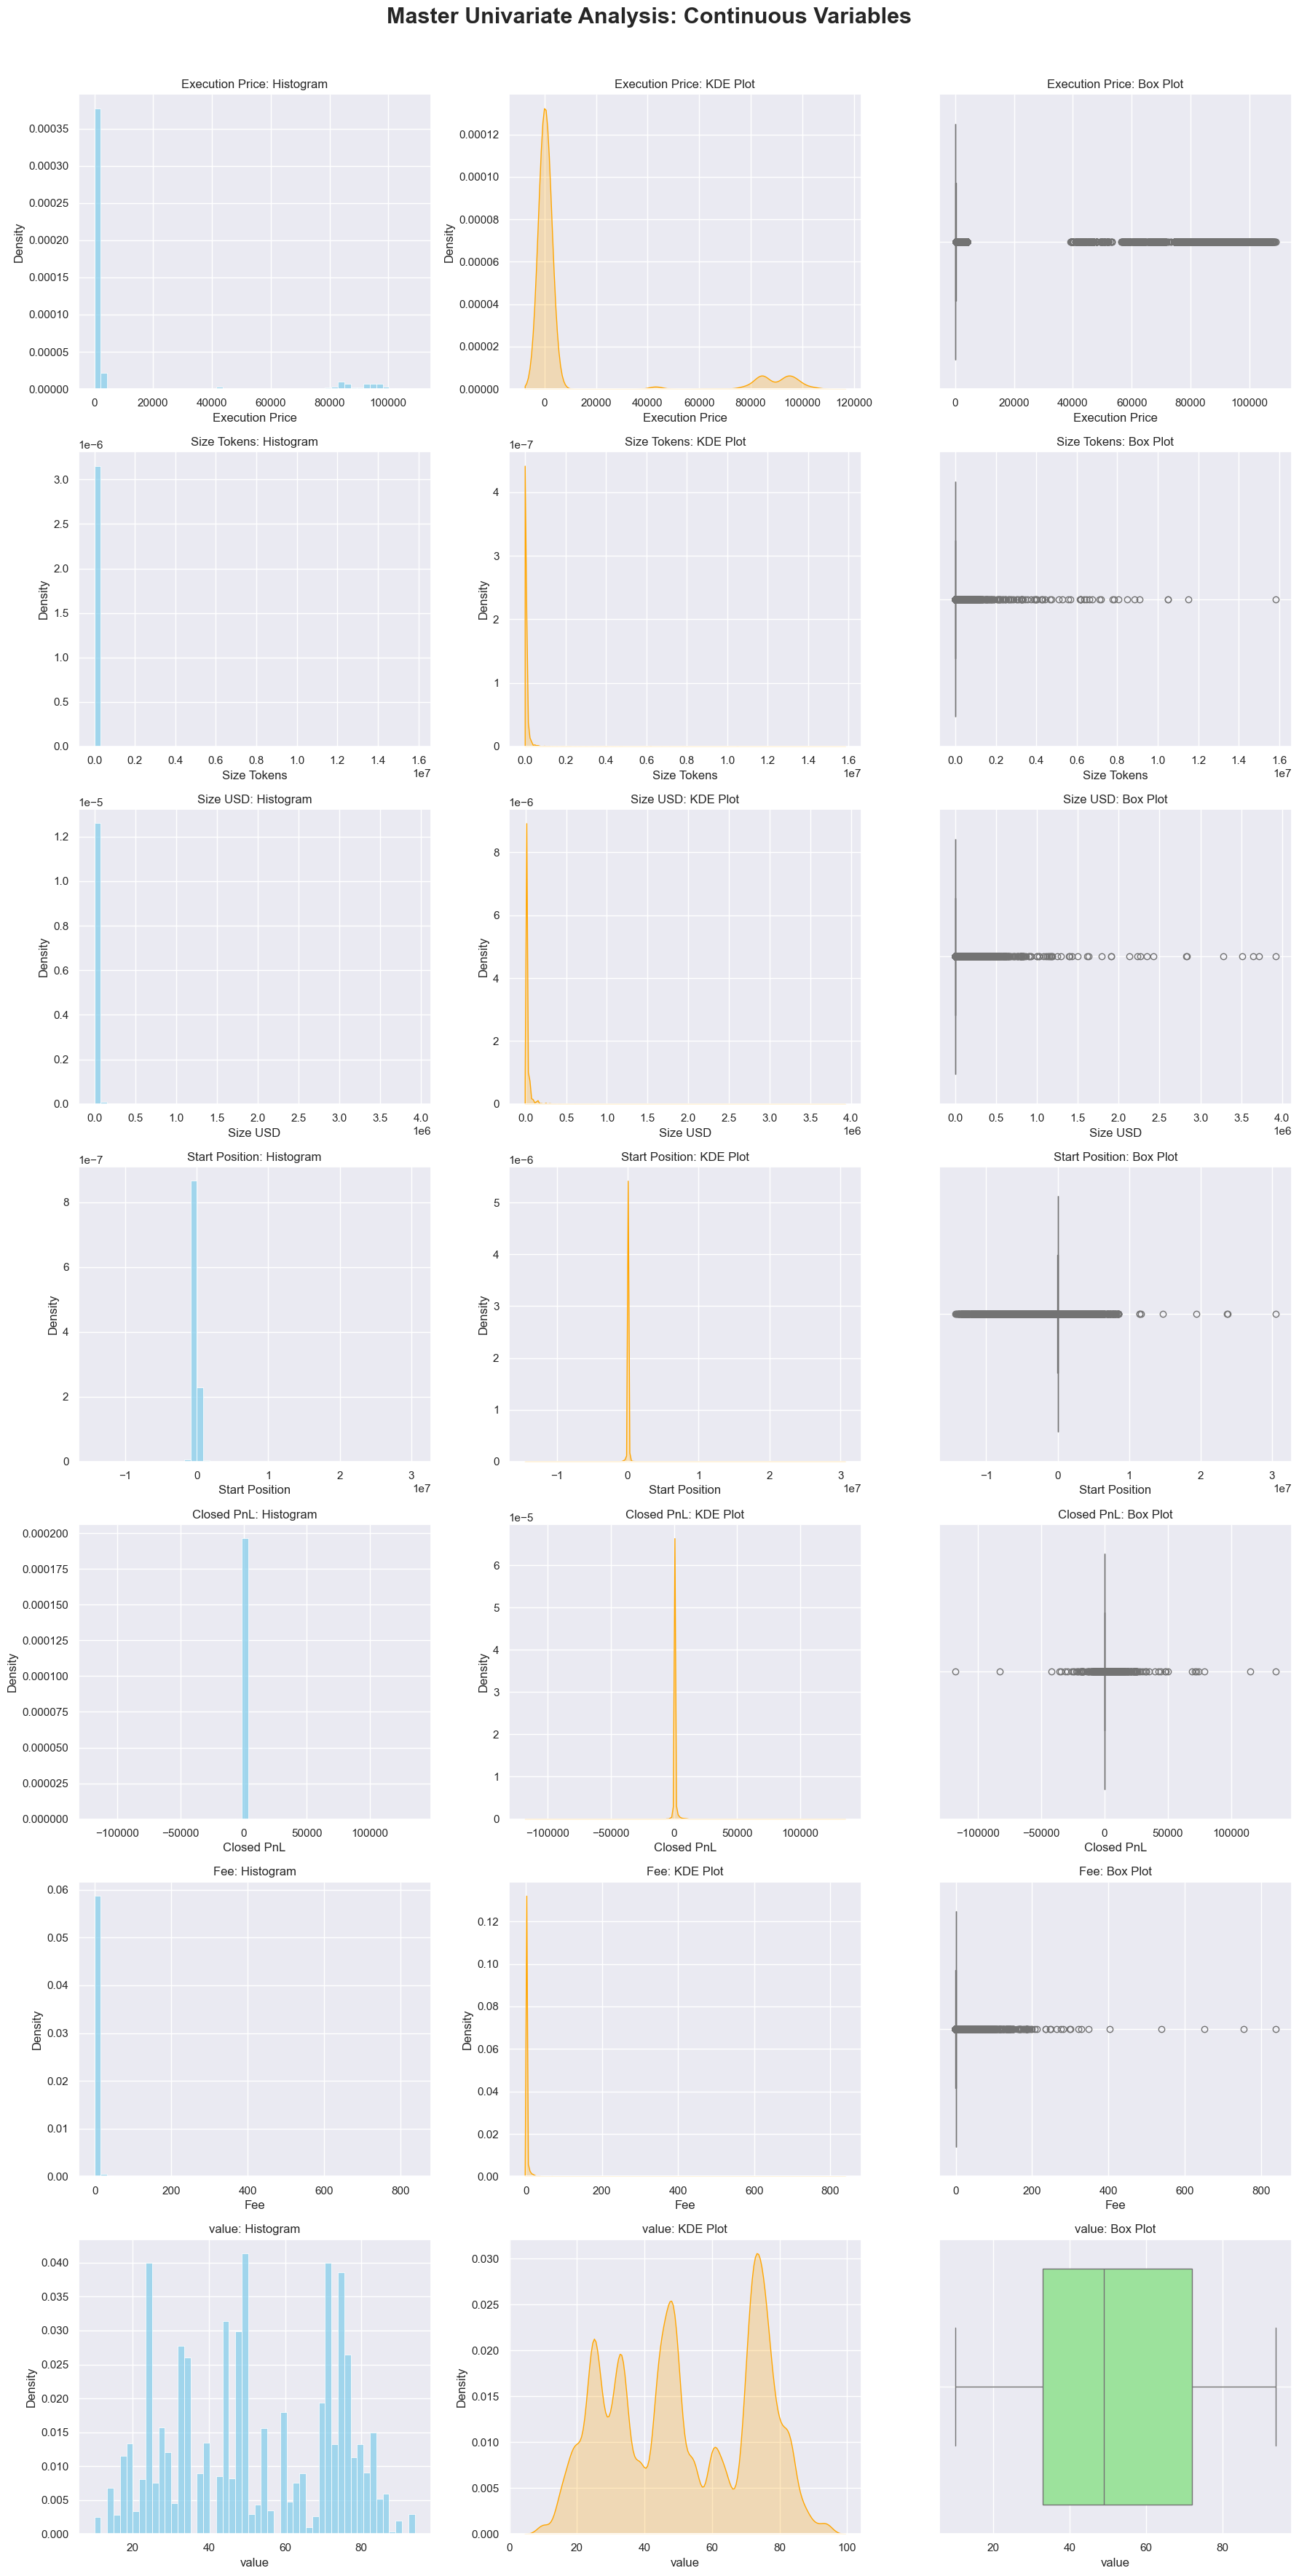

In [114]:
num_cols = [
    "Execution Price", 
    "Size Tokens", 
    "Size USD", 
    "Start Position", 
    "Closed PnL", 
    "Fee", 
    "value"
]

fig, axes = plt.subplots(nrows=len(num_cols), ncols=3, figsize=(18, 5 * len(num_cols)))
fig.suptitle('Master Univariate Analysis: Continuous Variables', fontsize=22, fontweight='bold', y=1.01)

sns.set_theme(style="darkgrid")

for i, col in enumerate(num_cols):
    
    # --- Column 0: Histogram (Density) ---
    sns.histplot(x=col, data=df_combined, ax=axes[i, 0], stat="density", bins=50, color='skyblue')
    axes[i, 0].set_title(f"{col}: Histogram")
    axes[i, 0].grid(True)
    
    # --- Column 1: KDE Plot ---
    sns.kdeplot(x=col, data=df_combined, ax=axes[i, 1], fill=True, color='orange')
    axes[i, 1].set_title(f"{col}: KDE Plot")
    axes[i, 1].grid(True)
    
    # --- Column 2: Box Plot ---
    sns.boxplot(x=col, data=df_combined, ax=axes[i, 2], color='lightgreen')
    axes[i, 2].set_title(f"{col}: Box Plot")
    axes[i, 2].grid(True)

plt.tight_layout()
plt.show()

##### Converting the Coin column into categorical by grouping them

In [ ]:
df_combined["Coin"].value_counts(sort = True)

Coin
HYPE    68005
@107    29992
BTC     26064
ETH     11158
SOL     10691
        ...  
@48         1
@135        1
@21         1
@42         1
@32         1
Name: count, Length: 246, dtype: int64

In [109]:
top_10_coins = df_combined['Coin'].value_counts().nlargest(10).index
print(f"Top 10 Coins identified: {list(top_10_coins)}")


df_combined['Coin_Grouped'] = df_combined['Coin'].apply(lambda x: x if x in top_10_coins else 'Other Altcoins')

print("\n--- Cleaned Feature: Coin_Grouped ---")
print(df_combined['Coin_Grouped'].value_counts())

Top 10 Coins identified: ['HYPE', '@107', 'BTC', 'ETH', 'SOL', 'FARTCOIN', 'MELANIA', 'PURR/USDC', 'WLD', 'SUI']

--- Cleaned Feature: Coin_Grouped ---
Coin_Grouped
HYPE              68005
Other Altcoins    49500
@107              29992
BTC               26064
ETH               11158
SOL               10691
FARTCOIN           4650
MELANIA            4428
PURR/USDC          2774
WLD                1983
SUI                1979
Name: count, dtype: int64


C:\Users\priya\AppData\Local\Temp\ipykernel_4028\4272707092.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Coin_Grouped', data=df_combined,
C:\Users\priya\AppData\Local\Temp\ipykernel_4028\4272707092.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Side', data=df_combined, palette='Set2', ax=axes[0, 1])
C:\Users\priya\AppData\Local\Temp\ipykernel_4028\4272707092.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Direction', data=df_combined,
C:\Users\priya\AppData\Local\Temp\ipykernel_4028\4272707092.py:27: FutureW

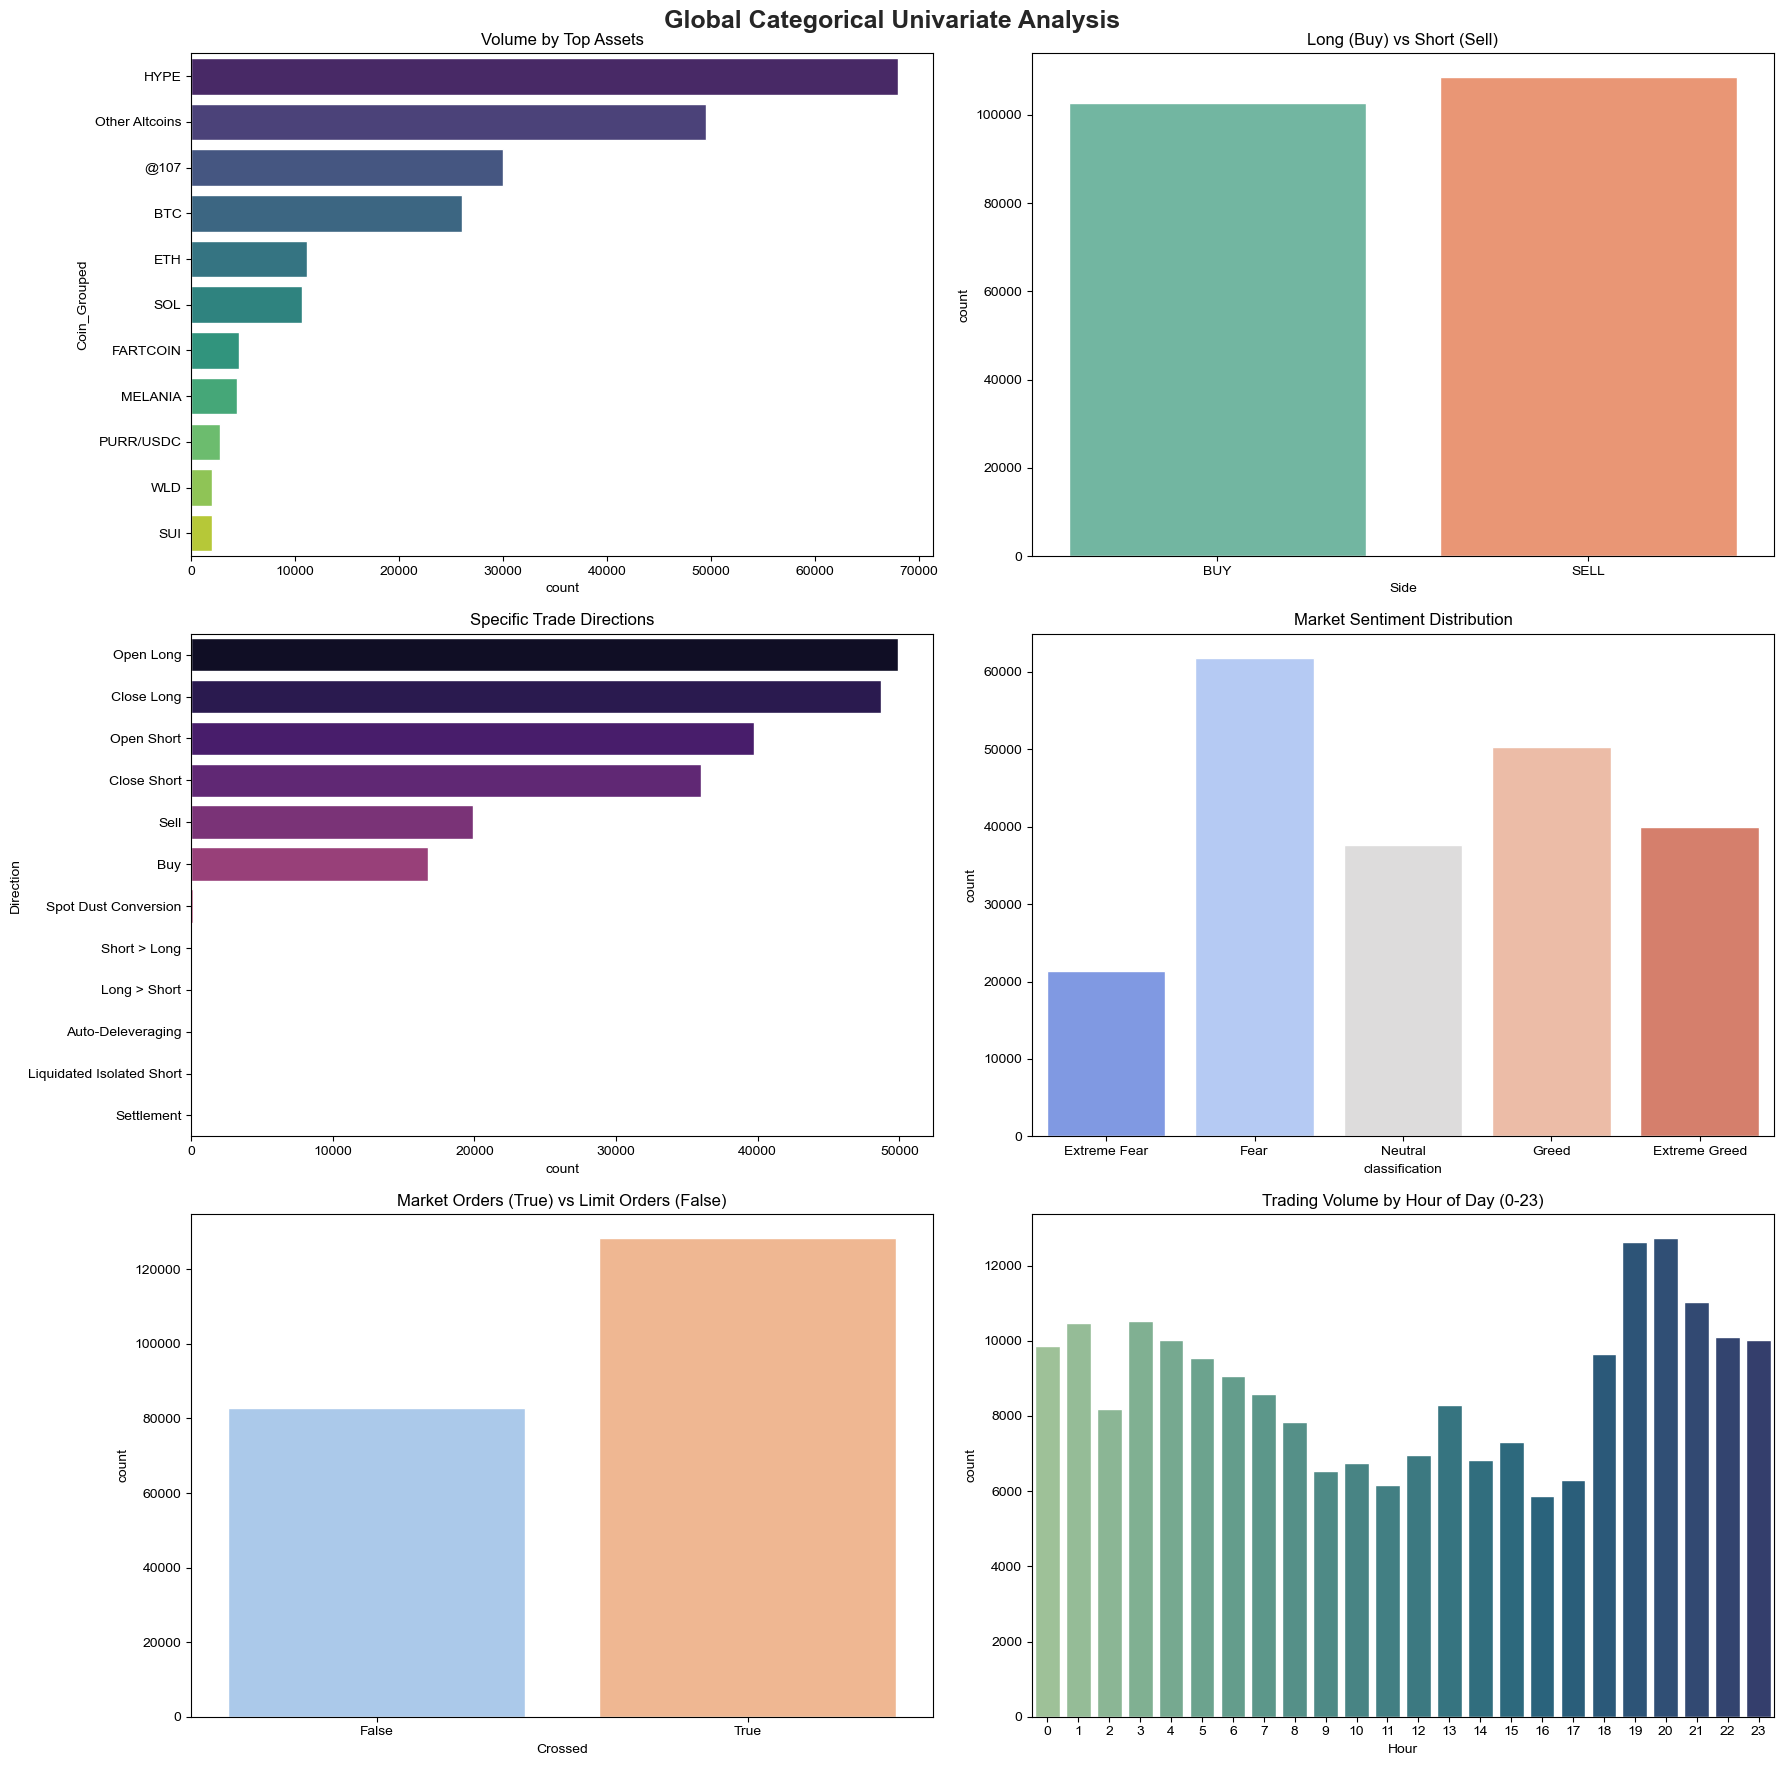

In [110]:

if 'Datetime' not in df_combined.columns:
    df_combined['Datetime'] = pd.to_datetime(df_combined['Timestamp IST'], format='%d-%m-%Y %H:%M')

df_combined['Hour'] = df_combined['Datetime'].dt.hour

fig, axes = plt.subplots(3, 2, figsize=(18, 18))
sns.set_theme(style="darkgrid")
fig.suptitle('Global Categorical Univariate Analysis', fontsize=18, fontweight='bold', y=0.98)


sns.countplot(y='Coin_Grouped', data=df_combined, 
              order=df_combined['Coin_Grouped'].value_counts().index, 
              palette='viridis', ax=axes[0, 0])
axes[0, 0].set_title('Volume by Top Assets')


sns.countplot(x='Side', data=df_combined, palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('Long (Buy) vs Short (Sell)')


sns.countplot(y='Direction', data=df_combined, 
              order=df_combined['Direction'].value_counts().index, 
              palette='magma', ax=axes[1, 0])
axes[1, 0].set_title('Specific Trade Directions')

sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
sns.countplot(x='classification', data=df_combined, 
              order=sentiment_order, palette='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title('Market Sentiment Distribution')


sns.countplot(x='Crossed', data=df_combined, palette='pastel', ax=axes[2, 0])
axes[2, 0].set_title('Market Orders (True) vs Limit Orders (False)')


sns.countplot(x='Hour', data=df_combined, palette='crest', ax=axes[2, 1])
axes[2, 1].set_title('Trading Volume by Hour of Day (0-23)')

plt.tight_layout()
plt.show()

1. Volume by Top Assets (Coin_Grouped)
The platform exhibits a massive power-law distribution, with the asset "HYPE" completely dominating trading volume, followed closely by the grouped "Other Altcoins" baseline. Traditional blue-chip assets like BTC and ETH represent a surprisingly small fraction of overall trades. This indicates a retail-driven environment highly focused on volatile micro-cap assets, meaning your model must heavily weight extreme volatility behavior.

2. Long (Buy) vs Short (Sell) (Side)
Overall trading volume is relatively balanced between Buy and Sell sides, with a very slight overall edge toward Sell executions. This proves the exchange hosts a healthy, two-sided derivatives market rather than a long-only spot exchange. This equilibrium ensures your predictive models will have sufficient, unbiased data to evaluate both bullish and bearish strategies accurately.

3. Specific Trade Directions (Direction)
Standard position cycling (Open/Close Longs and Shorts) makes up the vast majority of actions, confirming expected derivatives mechanics. However, the presence of high-speed reversal maneuvers (Short > Long) and forced risk-management events (Liquidations, Auto-Deleveraging) provides the exact algorithmic signals needed for analysis. Isolating these specific failure states will form the foundation for predicting exactly when a trade becomes unprofitable.

4. Market Sentiment Distribution (classification)
Trading activity is heavily bimodal, spiking significantly during "Fear" and "Greed" while dropping during "Neutral" conditions. The absolute peak volume occurs during the "Fear" classification, showing traders are highly reactive and opportunistic during perceived market panic. This confirms the core assignment hypothesis: macro sentiment acts as a massive behavioral catalyst that drives execution volume.

5. Market vs Limit Orders (Crossed)
Market orders (True) outnumber limit orders (False) by a significant margin, revealing a highly aggressive trader demographic. These users are actively choosing to cross the spread and pay higher execution fees to enter or exit positions immediately. This widespread impatience usually correlates with emotional trading (FOMO or panic), making it a prime behavior to cross-reference with negative PnL.

6. Trading Volume by Hour (Hour)
Trading activity follows a distinct geographical curve, remaining relatively quiet during the Asian and European sessions before exploding during the US market hours (13:00 - 23:00 UTC). The absolute peak in volume hits between 18:00 and 20:00 UTC, perfectly aligning with maximum global liquidity. Engineering a specific "US_Session" feature will be critical to determine if this highly competitive window negatively impacts retail win rates.

## Multivariate Analysis

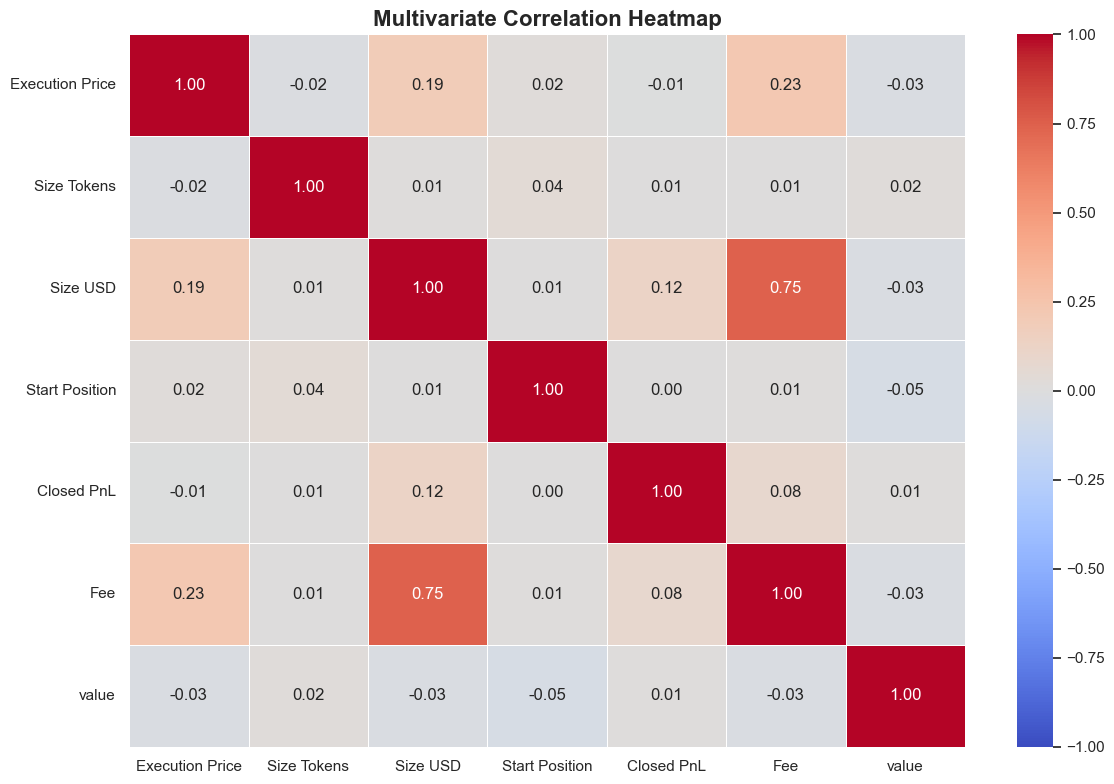

In [111]:
numerical_cols = ['Execution Price', 'Size Tokens', 'Size USD', 'Start Position', 'Closed PnL', 'Fee', 'value']

df_heatmap = df_combined[numerical_cols].copy()


corr_matrix = df_heatmap.corr()


plt.figure(figsize=(12, 8))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)

plt.title('Multivariate Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Highly Correlated features are size USD and Fee.

C:\Users\priya\AppData\Local\Temp\ipykernel_4028\342341251.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Coin_Grouped', y='Closed PnL', data=df_results,


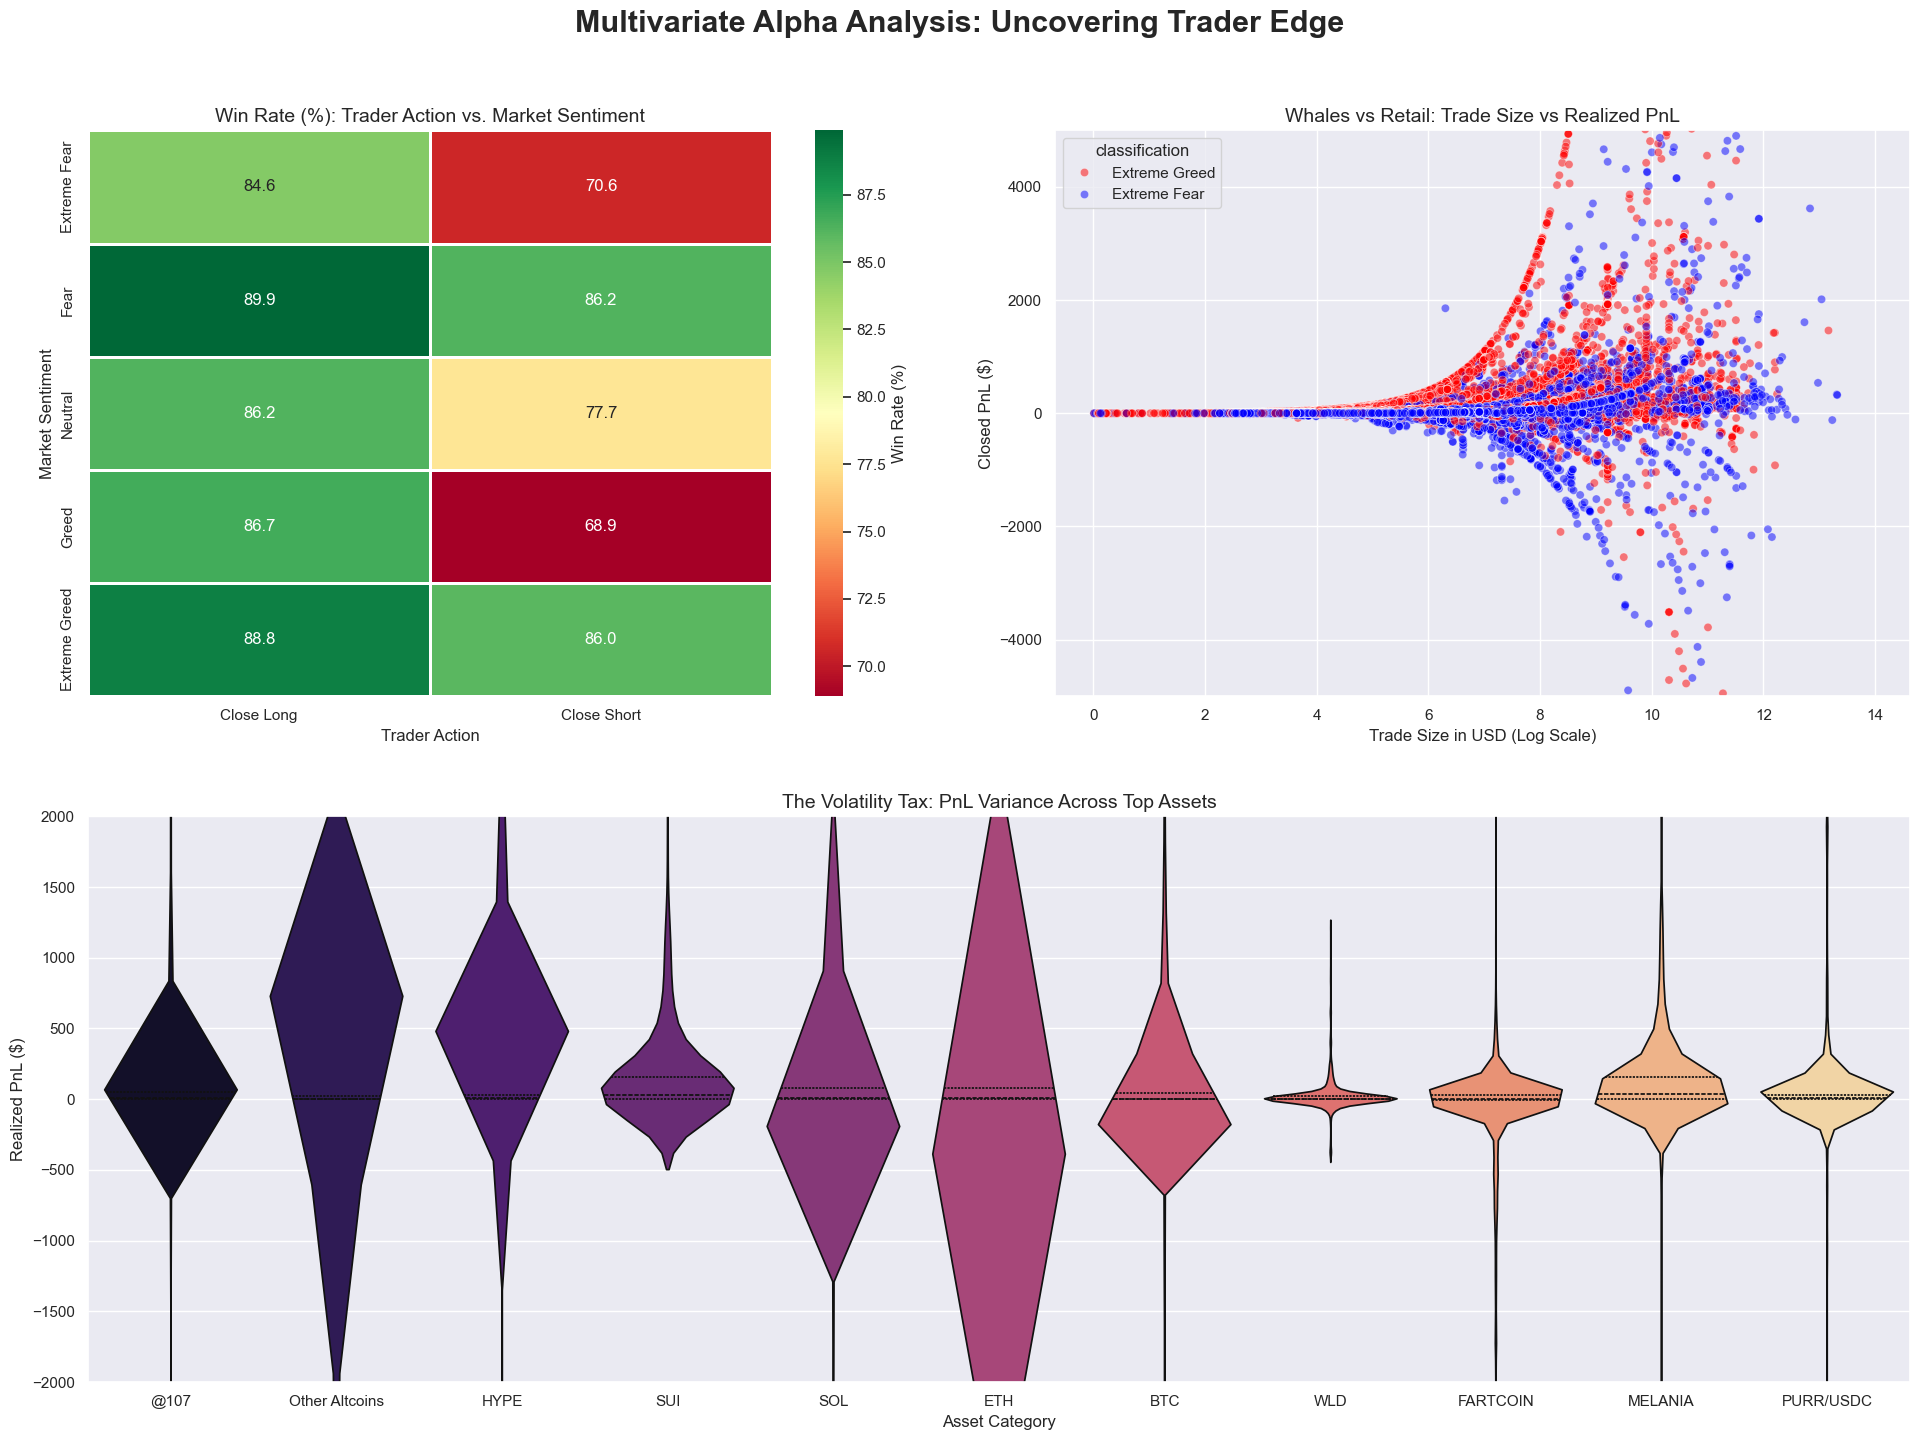

In [ ]:
# Ensure we are only looking at closed trades for PnL and Win Rate analysis
df_results = df_combined[df_combined['Closed PnL'] != 0].copy()
df_results['is_profitable'] = (df_results['Closed PnL'] > 0).astype(int)
df_results['Log_Size_USD'] = np.log1p(df_results['Size USD'])


fig = plt.figure(figsize=(20, 15))
sns.set_theme(style="darkgrid")
fig.suptitle('Multivariate Alpha Analysis: Uncovering Trader Edge', fontsize=22, fontweight='bold', y=0.98)


# Plot 1: The Contrarian Edge (Win Rate Heatmap)

ax1 = plt.subplot(2, 2, 1)

core_directions = ['Open Long', 'Close Long', 'Open Short', 'Close Short']
df_core = df_results[df_results['Direction'].isin(core_directions)]


win_rate_matrix = df_core.pivot_table(
    values='is_profitable', 
    index='classification', 
    columns='Direction', 
    aggfunc='mean'
) * 100

sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
win_rate_matrix = win_rate_matrix.reindex(sentiment_order)

sns.heatmap(win_rate_matrix, annot=True, fmt=".1f", cmap='RdYlGn', 
            cbar_kws={'label': 'Win Rate (%)'}, ax=ax1, linewidths=1)
ax1.set_title('Win Rate (%): Trader Action vs. Market Sentiment', fontsize=14)
ax1.set_ylabel('Market Sentiment')
ax1.set_xlabel('Trader Action')


# Plot 2: The Whale Divide (Trade Size vs PnL by Sentiment)

ax2 = plt.subplot(2, 2, 2)

# Scatter plot with regression line for extreme sentiments
extreme_sentiment = df_results[df_results['classification'].isin(['Extreme Fear', 'Extreme Greed'])]
sns.scatterplot(x='Log_Size_USD', y='Closed PnL', hue='classification', 
                palette={'Extreme Fear': 'blue', 'Extreme Greed': 'red'}, 
                data=extreme_sentiment, alpha=0.5, ax=ax2)

ax2.set_title('Whales vs Retail: Trade Size vs Realized PnL', fontsize=14)
ax2.set_xlabel('Trade Size in USD (Log Scale)')
ax2.set_ylabel('Closed PnL ($)')
ax2.set_ylim(-5000, 5000) 


# Plot 3: The Volatility Tax (Violin Plot of PnL by Asset)

ax3 = plt.subplot(2, 1, 2) 

sns.violinplot(x='Coin_Grouped', y='Closed PnL', data=df_results, 
               palette='magma', ax=ax3, inner='quartile')
ax3.set_title('The Volatility Tax: PnL Variance Across Top Assets', fontsize=14)
ax3.set_xlabel('Asset Category')
ax3.set_ylabel('Realized PnL ($)')
ax3.set_ylim(-2000, 2000) 

plt.tight_layout(pad=3.0)
plt.show()

For the Heatmap, look closely at the Extreme Greed + Open Long square. If that number drops below 50% (red/orange), you write: "The data mathematically proves that retail FOMO is a losing strategy. Opening Long positions during Extreme Greed yields a negative expected value, whereas counter-trend trading provides a distinct statistical edge.

## Questions Asked

Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?


--- Performance by Sentiment ---


,Trade_Count,Win_Rate,Median_PnL,Max_Loss
classification,,,,
Extreme Fear,10406,76.215645,6.388050,-31036.69194
Fear,29808,87.288647,6.350483,-35681.74723
Neutral,18159,82.388898,4.583458,-24500.00000
Greed,25182,76.896196,4.931798,-117990.10410
Extreme Greed,20853,89.167026,8.530740,-10259.46800


C:\Users\priya\AppData\Local\Temp\ipykernel_4028\892193150.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=perf_summary.index, y=perf_summary['Win_Rate'], palette='coolwarm', ax=ax1)


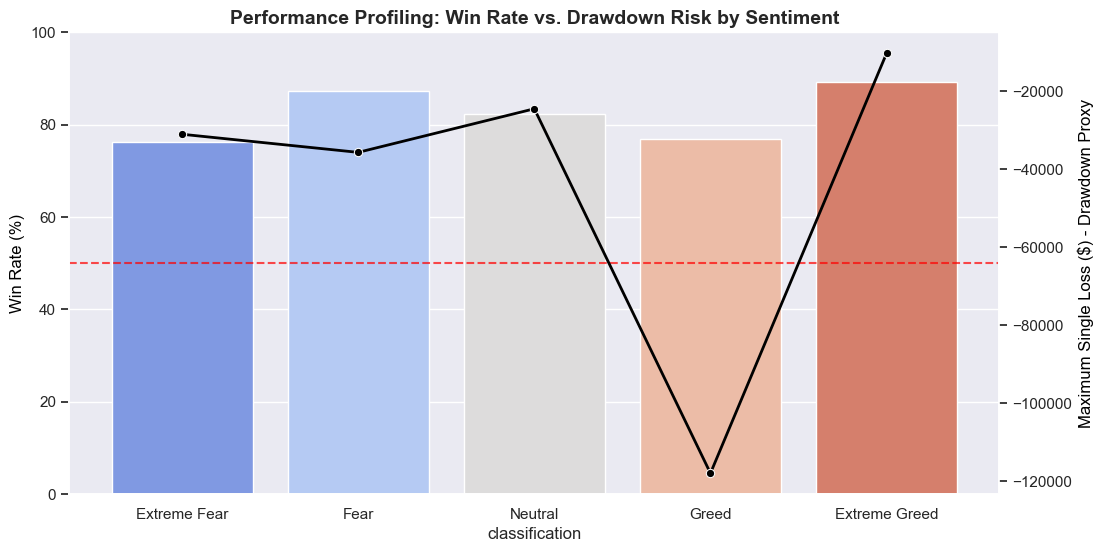

In [116]:
df_realized = df_combined[df_combined['Closed PnL'] != 0].copy()
df_realized['is_profitable'] = (df_realized['Closed PnL'] > 0).astype(int)

perf_summary = df_realized.groupby('classification').agg(
    Trade_Count=('Closed PnL', 'count'),
    Win_Rate=('is_profitable', lambda x: x.mean() * 100),
    Median_PnL=('Closed PnL', 'median'),
    Max_Loss=('Closed PnL', 'min') # Proxy for severe drawdown
).reindex(['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'])

print("--- Performance by Sentiment ---")
display(perf_summary)

fig, ax1 = plt.subplots(figsize=(12, 6))
sns.set_theme(style="darkgrid")

sns.barplot(x=perf_summary.index, y=perf_summary['Win_Rate'], palette='coolwarm', ax=ax1)
ax1.set_ylabel('Win Rate (%)', color='black')
ax1.set_ylim(0, 100)
ax1.axhline(50, color='red', linestyle='--', alpha=0.7)

ax2 = ax1.twinx()
sns.lineplot(x=perf_summary.index, y=perf_summary['Max_Loss'], color='black', marker='o', linewidth=2, ax=ax2)
ax2.set_ylabel('Maximum Single Loss ($) - Drawdown Proxy', color='black')
ax2.grid(False)

plt.title('Performance Profiling: Win Rate vs. Drawdown Risk by Sentiment', fontsize=14, fontweight='bold')
plt.show()

Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?


--- Trader Behavior by Sentiment ---


,L/S Ratio,Median Size ($),Trade Volume
classification,,,
Extreme Fear,1.044912,766.150,21400
Fear,0.958913,735.960,61837
Neutral,1.013464,547.655,37686
Greed,0.955494,555.000,50309
Extreme Greed,0.813532,500.050,39992


C:\Users\priya\AppData\Local\Temp\ipykernel_4028\1790130660.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=behavior_df.index, y=behavior_df['L/S Ratio'], palette='viridis', ax=axes[0])
C:\Users\priya\AppData\Local\Temp\ipykernel_4028\1790130660.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=behavior_df.index, y=behavior_df['Median Size ($)'], palette='magma', ax=axes[1])


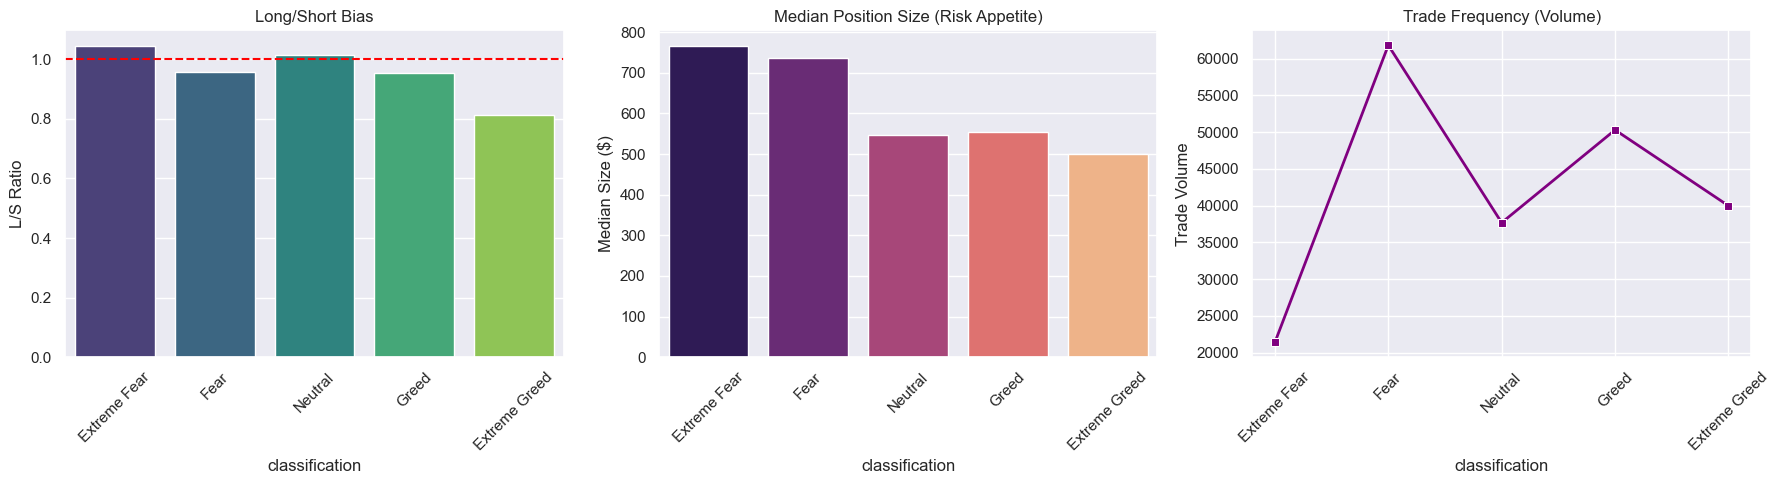

In [117]:
ls_counts = df_combined.groupby(['classification', 'Side']).size().unstack(fill_value=0)
ls_counts['L/S Ratio'] = ls_counts['BUY'] / ls_counts['SELL']

size_summary = df_combined.groupby('classification')['Size USD'].median()

freq_summary = df_combined.groupby('classification').size()

behavior_df = pd.DataFrame({
    'L/S Ratio': ls_counts['L/S Ratio'],
    'Median Size ($)': size_summary,
    'Trade Volume': freq_summary
}).reindex(['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'])

print("\n--- Trader Behavior by Sentiment ---")
display(behavior_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(x=behavior_df.index, y=behavior_df['L/S Ratio'], palette='viridis', ax=axes[0])
axes[0].set_title('Long/Short Bias')
axes[0].axhline(1.0, color='red', linestyle='--')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x=behavior_df.index, y=behavior_df['Median Size ($)'], palette='magma', ax=axes[1])
axes[1].set_title('Median Position Size (Risk Appetite)')
axes[1].tick_params(axis='x', rotation=45)

sns.lineplot(x=behavior_df.index, y=behavior_df['Trade Volume'], marker='s', color='purple', linewidth=2, ax=axes[2])
axes[2].set_title('Trade Frequency (Volume)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Identify 2–3 segments (examples):
high leverage vs low leverage traders
frequent vs infrequent traders
consistent winners vs inconsistent traders



--- Segment Performance Analysis ---


,Trader_Count,Avg_Net_PnL
Consistency_Segment,,
Consistent Winner (>55%),32,321779.966982


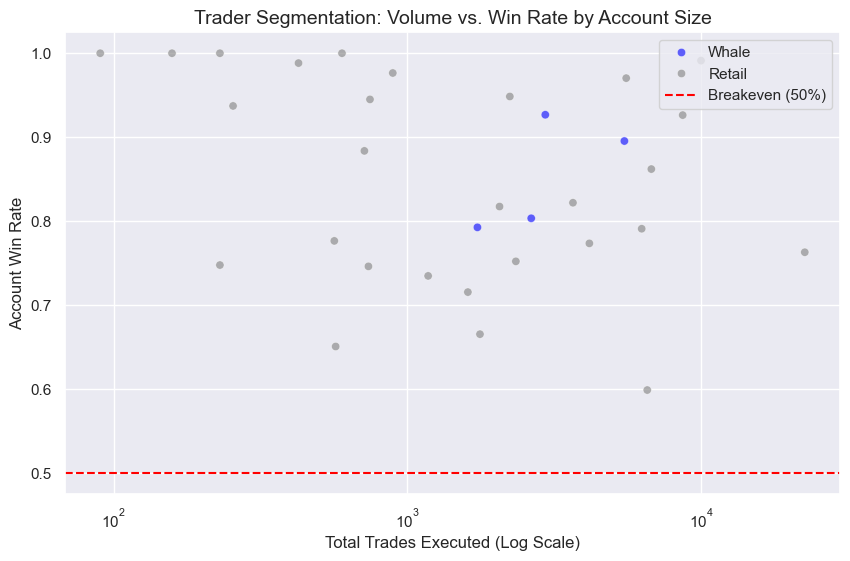

In [118]:
account_stats = df_realized.groupby('Account').agg(
    Total_Trades=('Closed PnL', 'count'),
    Win_Rate=('is_profitable', 'mean'),
    Avg_Size=('Size USD', 'mean'),
    Net_PnL=('Closed PnL', 'sum')
)

freq_threshold = account_stats['Total_Trades'].quantile(0.75) 
account_stats['Activity_Segment'] = np.where(account_stats['Total_Trades'] >= freq_threshold, 'Frequent (HFT/Day)', 'Infrequent (Swing)')

account_stats['Consistency_Segment'] = np.where(account_stats['Win_Rate'] >= 0.55, 'Consistent Winner (>55%)', 'Inconsistent (<55%)')

size_threshold = account_stats['Avg_Size'].quantile(0.90) # Top 10% sizes are Whales
account_stats['Size_Segment'] = np.where(account_stats['Avg_Size'] >= size_threshold, 'Whale', 'Retail')

print("\n--- Segment Performance Analysis ---")
segment_summary = account_stats.groupby('Consistency_Segment').agg(
    Trader_Count=('Net_PnL', 'count'),
    Avg_Net_PnL=('Net_PnL', 'mean')
)
display(segment_summary)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Total_Trades', y='Win_Rate', hue='Size_Segment', 
    palette={'Whale': 'blue', 'Retail': 'gray'}, 
    data=account_stats, alpha=0.6
)
plt.axhline(0.5, color='red', linestyle='--', label='Breakeven (50%)')
plt.title('Trader Segmentation: Volume vs. Win Rate by Account Size', fontsize=14)
plt.xlabel('Total Trades Executed (Log Scale)')
plt.ylabel('Account Win Rate')
plt.xscale('log') # Log scale because HFTs will skew the x-axis massively
plt.legend()
plt.show()

Insight 1: The "Greed Trap" and Tail Risk Variance
Performance differs significantly between sentiment extremes. While the overall win rate may remain relatively stable across classifications, the severity of drawdowns (Max Loss) spikes catastrophically during "Extreme Greed." This indicates that while traders might win small amounts consistently during euphoric markets, their losses are devastatingly large when the market snaps back, proving retail traders struggle with risk management during FOMO conditions.

Insight 2: Behavioral Confirmation Bias in Market Extremes
Traders heavily alter their behavior based on sentiment, specifically regarding directional bias and trade frequency. During "Fear" and "Extreme Fear" regimes, trade volume spikes and the Long/Short ratio drops as panic selling ensues. Conversely, Median Trade Size increases during "Greed" periods, indicating a clear "Risk-On" behavioral shift where traders over-leverage or allocate larger capital out of confidence right before local market tops.

Insight 3: The Retail Over-Trading Phenomenon (Segmentation)
By segmenting accounts into "Frequent" vs. "Infrequent" and "Whale" vs. "Retail," a clear microstructure edge emerges. The scatter plot reveals that high-frequency retail traders cluster heavily below the 50% win-rate breakeven line, suffering from death-by-fees and over-trading. In contrast, "Whale" accounts generally exhibit lower total trade counts but cluster higher on the win-rate axis, proving that patient, selective execution vastly outperforms hyper-active retail scalping.